<a href="https://colab.research.google.com/github/joyekansh/Ml-projects/blob/main/churn_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Customer-Churn.csv')

missing_value = df.isnull().sum()
print(missing_value)
print("--------------")
print(df.info())
print("--------------")
print(df.value_counts())
df

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
--------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
data = df.drop('customerID',axis = 1)
data['TotalCharges'] = data['TotalCharges'].replace(' ',0.0)
data['TotalCharges'] = data['TotalCharges'].astype(float)

data['MultipleLines'] = data['MultipleLines'].replace('No phone service','No')
conversion_list_param = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
data[conversion_list_param] = data[conversion_list_param].replace('No internet service','No')
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.5 MB/s eta 0:00:00


In [ ]:
from sklearn import preprocessing
x = data.drop('Churn',axis = 1)
y = data['Churn']

from sklearn.model_selection import train_test_split

x_train ,x_test ,y_train, y_test = train_test_split(x,y,random_state=42,shuffle = True)
x_train_raw,x_valid_raw ,y_train_raw,y_valid_raw = train_test_split(x_train,y_train,random_state=42,shuffle = True)

from sklearn.preprocessing import StandardScaler,OrdinalEncoder,OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_data = ['tenure','MonthlyCharges','TotalCharges']
one_hot_data = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','InternetService','PaymentMethod', 'gender'] # Added 'gender' here
ordinal_data = ['Contract']
ordinal_order = ['Month-to-month','One year','Two year']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_data),
        ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False), one_hot_data),
        ('ordinal', OrdinalEncoder(categories=[ordinal_order]), ordinal_data)
    ],
    remainder = 'passthrough'
)

x_train_transformed = preprocessor.fit_transform(x_train_raw)
x_valid_transformed = preprocessor.transform(x_valid_raw)

le = LabelEncoder()
y_train_ = le.fit_transform(y_train_raw).reshape(-1, 1)
y_valid = le.transform(y_valid_raw).reshape(-1, 1)

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam,SGD,RMSprop
import keras_tuner as kt

def model_buider(hp):

  model = Sequential()

  num_layers = hp.Int('layer',min_value = 1, max_value = 3, step =1)
  units = hp.Int('units',min_value = 32,max_value = 128,step = 32)
  optim = hp.Choice('optim',values = ['adam','sgd','rmsprop'])

  model.add(Dense(units=units,activation='relu',input_shape = (x_train_transformed.shape[1],)))

  for i in range(1,num_layers):

    model.add(Dense(units = units,activation='relu'))

  model.add(Dense(units = 1, activation='sigmoid'))

  model.compile(optimizer=optim, loss='binary_crossentropy', metrics=['accuracy','Precision','Recall','AUC','F1Score'])

  return model

In [ ]:
tuner = kt.Hyperband(
    model_buider,
    objective = kt.Objective('val_accuracy', direction='max'),
    max_epochs = 10,
    factor = 3,
    directory = 'tuner_log',
    project_name = 'churn_data_log'
)

tuner.search(x_train_transformed, y_train_, epochs = 20, validation_data=(x_valid_transformed, y_valid))

Trial 30 Complete [00h 00m 11s]
val_accuracy: 0.797123372554779

Best val_accuracy So Far: 0.8031793832778931
Total elapsed time: 00h 04m 11s


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_models = tuner.get_best_models(num_models=2)
optimal_model= best_models[0]

x_test_transformed = preprocessor.transform(x_test)
y_test_encoded = le.transform(y_test).reshape(-1, 1)

history = optimal_model.fit(
    x = x_train_transformed,
    y = y_train_,
    epochs = 100,
    batch_size = 32,
    validation_data = (x_valid_transformed ,y_valid)
)

test_loss, test_accuracy, _, _, _, _ = optimal_model.evaluate(x_test_transformed, y_test_encoded, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_proba = optimal_model.predict(x_test_transformed)
y_pred = (y_pred_proba > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))


Epoch 1/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - AUC: 0.8416 - F1Score: 0.3994 - Precision: 0.6754 - Recall: 0.5078 - accuracy: 0.8163 - loss: 0.4093 - val_AUC: 0.8395 - val_F1Score: 0.4227 - val_Precision: 0.5989 - val_Recall: 0.5904 - val_accuracy: 0.7843 - val_loss: 0.4288
Epoch 2/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8606 - F1Score: 0.4036 - Precision: 0.6883 - Recall: 0.5806 - accuracy: 0.8271 - loss: 0.3911 - val_AUC: 0.8373 - val_F1Score: 0.4227 - val_Precision: 0.6618 - val_Recall: 0.5085 - val_accuracy: 0.7986 - val_loss: 0.4264
Epoch 3/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8618 - F1Score: 0.4272 - Precision: 0.7231 - Recall: 0.5647 - accuracy: 0.8230 - loss: 0.4014 - val_AUC: 0.8389 - val_F1Score: 0.4227 - val_Precision: 0.6949 - val_Recall: 0.4633 - val_accuracy: 0.8017 - val_loss: 0.4275
Epoch 4/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8645 - F1Score: 0.4079 - Precision: 0.6939 - Recall: 0.5162 - accuracy: 0.8169 - loss: 0

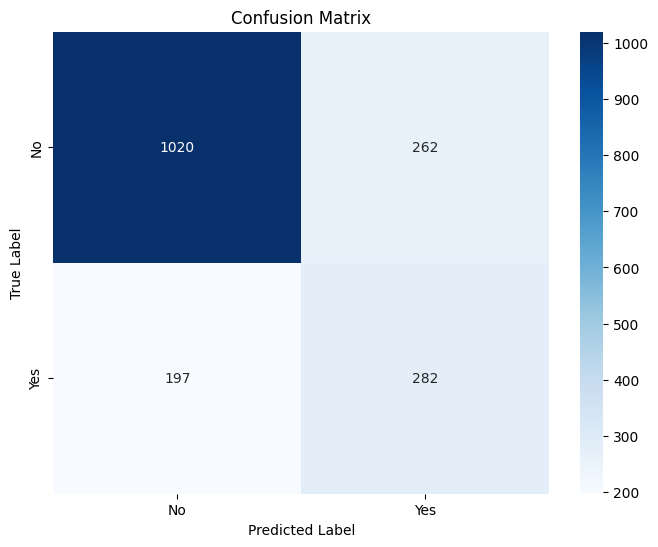

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test_encoded, y_pred, target_names=le.classes_, output_dict=True)

accuracy = report['accuracy']
precision_yes = report['Yes']['precision']
recall_yes = report['Yes']['recall']
f1_score_yes = report['Yes']['f1-score']

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision (for 'Yes' class): {precision_yes:.2f}")
print(f"Recall (for 'Yes' class): {recall_yes:.2f}")
print(f"F1-score (for 'Yes' class): {f1_score_yes:.2f}")

Accuracy: 0.74
Precision (for 'Yes' class): 0.52
Recall (for 'Yes' class): 0.59
F1-score (for 'Yes' class): 0.55
